In [ ]:
#exercise 1 - CIFAR-10 Classification with a Non-Deep Learning Mod

In [5]:
# Import libraries Exercise 1a: Loading and Exploring the CIFAR-10 Dataset python
import numpy as np
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print("Training data shape:", X_train.shape, "Labels shape:",
y_train.shape)
print("Test data shape:", X_test.shape, "Labels shape:", y_test.shape)

# Print the first 5 training labels
print("First 5 training labels:", y_train[:5].ravel())

Training data shape: (50000, 32, 32, 3) Labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3) Labels shape: (10000, 1)
First 5 training labels: [6 9 9 4 1]


In [25]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

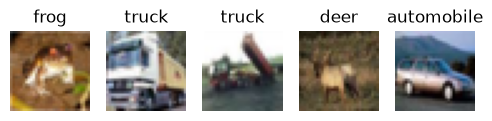

In [26]:
import matplotlib.pyplot as plt

# Define the class names for reference
class_names = ["airplane", "automobile", "bird", "cat", "deer",
"dog", "frog", "horse", "ship", "truck"]

# Plot a grid of 5 sample images from the training set
plt.figure(figsize=(6,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis('off') # Hide axes ticks
plt.show()

In [7]:
#Exercise 1b: Preprocessing-Reshaping and Normalization

# Convert images from [0,255] to [0,1] for numerical stability
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten the images into 1D vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1) # shape becomes
(50000, 3072)
X_test_flat = X_test.reshape(X_test.shape[0], -1) # shape becomes
(10000, 3072)

# Also flatten the label arrays from shape (N,1) to (N,) for use in scikit-learn
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()
print("After flattening: ", X_train_flat.shape, y_train_flat.shape)

After flattening:  (50000, 3072) (50000,)


In [8]:
#Exercise 1c: Training and Evaluating a Random Forest Classifier
import sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Initialize Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model (this might take a few minutes)
rf_clf.fit(X_train_flat, y_train_flat)

# Make predictions on the test set
y_pred_rf = rf_clf.predict(X_test_flat)

# Calculate accuracy
acc_rf = accuracy_score(y_test_flat, y_pred_rf)
print(f"Random Forest test accuracy: {acc_rf:.4f}")

Random Forest test accuracy: 0.4654


In [9]:
cm_rf = confusion_matrix(y_test_flat, y_pred_rf)
print("Confusion matrix:\n", cm_rf)

Confusion matrix:
 [[560  37  61  20  30  21  19  28 165  59]
 [ 31 542  12  38  21  34  45  36  66 175]
 [ 99  36 334  83 139  66 122  55  35  31]
 [ 55  46  74 281  89 173 134  60  23  65]
 [ 54  21 139  61 382  44 159  93  26  21]
 [ 31  27  93 167  74 399  77  73  26  33]
 [ 13  30  86  78 101  54 566  32   6  34]
 [ 46  45  54  59 104  83  36 452  23  98]
 [ 89  85  18  32  16  40   8  22 614  76]
 [ 50 177  18  37  21  23  26  44  80 524]]


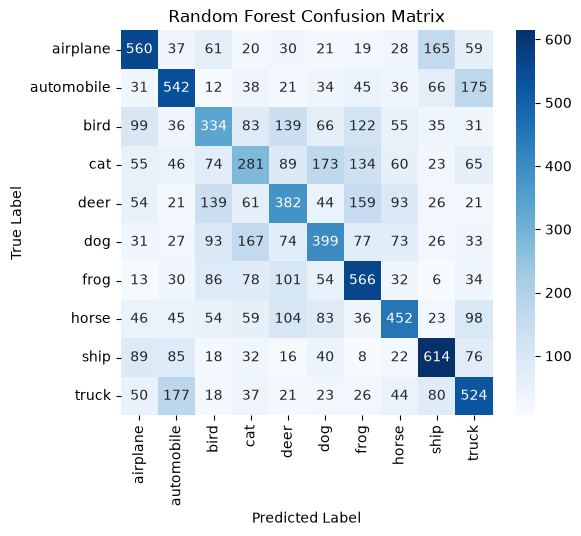

In [11]:
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
xticklabels=class_names, yticklabels=class_names)
plt.title("Random Forest Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [12]:
#Exercise 2: CIFAR-10 Classification with an Artificial Neural Network (ANN)

In [ ]:
#Exercise 2a: Preparing Data for the Neural Network



In [14]:
# Normalize the flattened images from [0, 1] to [-1, 1]
X_train_flat = (X_train_flat - 0.5) * 2.0
X_test_flat = (X_test_flat - 0.5) * 2.0

In [17]:
#Exercise 2b: Building the Neural Network (Model Architecture)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Initialize the Sequential model
model = Sequential()

# 2. Add the first hidden layer with 512 neurons and ReLU, and input dimension of 3072
model.add(Dense(units=512, activation='relu', input_shape=(3072,)))

# Add dropout to reduce overfitting
model.add(Dropout(0.3))

# 3. Add second hidden layer with 256 neurons and ReLU
model.add(Dense(units=256, activation='relu'))

# Add dropout to reduce overfitting
model.add(Dropout(0.3))

# 4. Add third hidden layer with 128 neurons and ReLU
model.add(Dense(units=128, activation='relu'))

# 5. Add output layer with 10 neurons and softmax activation
model.add(Dense(units=10, activation='softmax'))

# Summarize the model architecture
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Exercise 2c: Compiling and Training the Neural Network
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
# Train the model for, say, 25 epochs with a validation split of 10%
history = model.fit(X_train_flat, y_train,
epochs=25, batch_size=128,
validation_split=0.1, verbose=2)

Epoch 1/25
352/352 - 3s - 9ms/step - accuracy: 0.3367 - loss: 1.8613 - val_accuracy: 0.4068 - val_loss: 1.6789
Epoch 2/25
352/352 - 2s - 7ms/step - accuracy: 0.4022 - loss: 1.6785 - val_accuracy: 0.4502 - val_loss: 1.5813
Epoch 3/25
352/352 - 3s - 8ms/step - accuracy: 0.4331 - loss: 1.5992 - val_accuracy: 0.4742 - val_loss: 1.5174
Epoch 4/25
352/352 - 3s - 9ms/step - accuracy: 0.4544 - loss: 1.5380 - val_accuracy: 0.4838 - val_loss: 1.4755
Epoch 5/25
352/352 - 3s - 8ms/step - accuracy: 0.4745 - loss: 1.4827 - val_accuracy: 0.4896 - val_loss: 1.4436
Epoch 6/25
352/352 - 3s - 8ms/step - accuracy: 0.4862 - loss: 1.4414 - val_accuracy: 0.5040 - val_loss: 1.4238
Epoch 7/25
352/352 - 3s - 7ms/step - accuracy: 0.5008 - loss: 1.4030 - val_accuracy: 0.5118 - val_loss: 1.3991
Epoch 8/25
352/352 - 3s - 7ms/step - accuracy: 0.5133 - loss: 1.3747 - val_accuracy: 0.5200 - val_loss: 1.3767
Epoch 9/25
352/352 - 3s - 7ms/step - accuracy: 0.5220 - loss: 1.3413 - val_accuracy: 0.5262 - val_loss: 1.3713
E

In [20]:
#Exercise 2d: Evaluating and Visualizing the ANN Performance
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"Neural Network test accuracy: {test_accuracy:.4f}")

Neural Network test accuracy: 0.5463


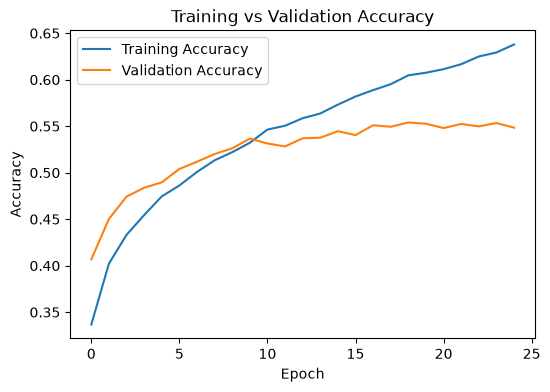

In [21]:
# Plot training & validation accuracy over epochs
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

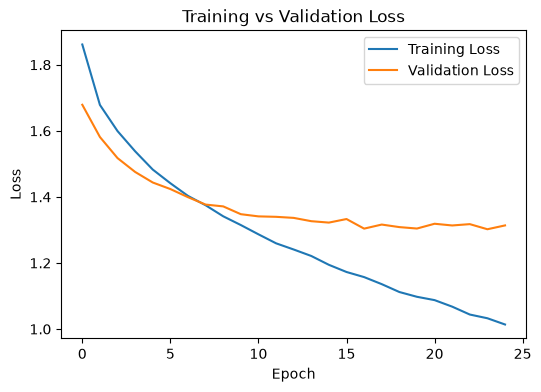

In [22]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


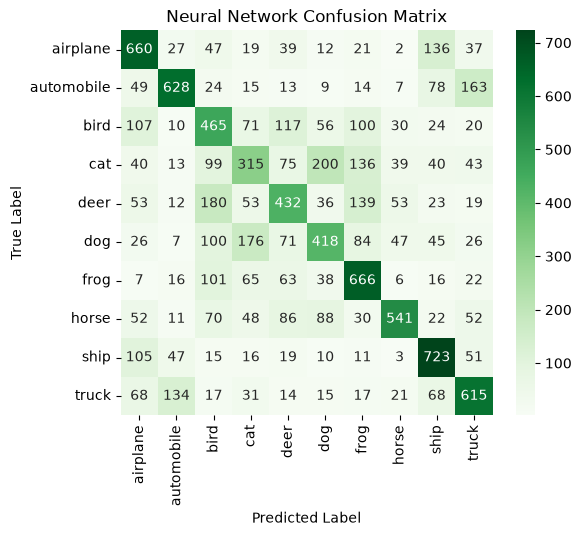

In [23]:
#confusion matrix for ANN
# Predict classes for test set using the trained model
y_pred_prob = model.predict(X_test_flat) # probabilities for each classs

y_pred_classes = np.argmax(y_pred_prob, axis=1) # choose the class with highest probability for each sample

# Compute confusion matrix for ANN predictions
cm_ann = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Greens",
xticklabels=class_names, yticklabels=class_names)
plt.title("Neural Network Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

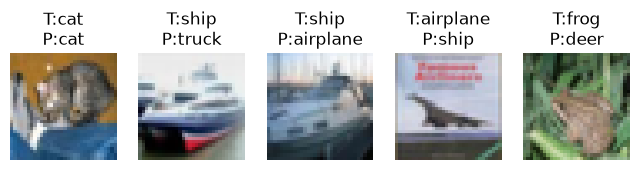

In [27]:
#optional sample predictions
# Pick a few random test images
samples = [0, 1, 2, 3, 4] # indices of test images to check (change asdesired)
plt.figure(figsize=(8,2))
for i, idx in enumerate(samples):
    plt.subplot(1, len(samples), i+1)
    plt.imshow(X_test[idx]) # show the image (remember X_test is still 32x32x3 in [0,1] range)
    true_label = class_names[int(y_test[idx][0])]
    pred_label = class_names[y_pred_classes[idx]]
    plt.title(f"T:{true_label}\nP:{pred_label}")
    plt.axis('off')
plt.show()